In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import confusion_matrix

In [3]:
transform = transforms.ToTensor()

In [4]:
train_data = datasets.MNIST(root='../Data',train=True,download=True,transform=transform)

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../Data/MNIST/raw/train-images-idx3-ubyte.gz to ../Data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../Data/MNIST/raw/train-labels-idx1-ubyte.gz to ../Data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ../Data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../Data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ../Data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../Data/MNIST/raw



In [6]:
test_data = datasets.MNIST(root='../Data',train=False,download=True,transform=transform)

In [7]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [8]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [9]:
train_loader = DataLoader(train_data,batch_size=10,shuffle=True)

In [10]:
test_loader = DataLoader(test_data,batch_size=10,shuffle=False)

In [11]:
class ConvolutionalNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,3,1)
        self.conv2 = nn.Conv2d(6,16,3,1)
        self.fc1 = nn.Linear(5*5*16,120)
        self.fc2 = nn.Linear(120,84)
        self.fc3 = nn.Linear(84,10)

    def forward(self,X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X,2,2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X,2,2)
        X = X.view(-1,5*5*16)
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(X,dim=1)

In [12]:
torch.manual_seed(13)
model = ConvolutionalNetwork()
model

ConvolutionalNetwork(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [20]:
import time
start_time = time.time()

epochs = 5
train_losses = []
test_losses = []
train_correct = []
test_correct = []

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0

    for b,(X_train,y_train) in enumerate(train_loader):
        b+=1

        y_pred = model(X_train)
        loss = criterion(y_pred,y_train)

        predicted = torch.max(y_pred.data,1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b%1500 == 0:
             print(f'epoch: {i:2}  batch: {b:4} [{10*b:6}/60000]  loss: {loss.item():10.8f}  \
accuracy: {trn_corr.item()*100/(10*b):7.3f}%')

    train_losses.append(loss.item())
    train_correct.append(trn_corr.item())

    with torch.no_grad():
        for b,(X_test,y_test) in enumerate (test_loader):
            y_val = model(X_test)

            predicted = torch.max(y_val.data,1)[1]
            tst_corr += (predicted == y_test).sum()

        loss = criterion(y_val,y_test)
        test_losses.append(loss.item())
        test_correct.append(tst_corr.item())


print(f"\nDuration: {time.time() - start_time:.0f} Seconds")

epoch:  0  batch: 1500 [ 15000/60000]  loss: 0.00104558  accuracy:  99.400%
epoch:  0  batch: 3000 [ 30000/60000]  loss: 0.02031635  accuracy:  99.363%
epoch:  0  batch: 4500 [ 45000/60000]  loss: 0.00051128  accuracy:  99.316%
epoch:  0  batch: 6000 [ 60000/60000]  loss: 0.00021601  accuracy:  99.295%
epoch:  1  batch: 1500 [ 15000/60000]  loss: 0.00001531  accuracy:  99.427%
epoch:  1  batch: 3000 [ 30000/60000]  loss: 0.00001932  accuracy:  99.453%
epoch:  1  batch: 4500 [ 45000/60000]  loss: 0.00002398  accuracy:  99.382%
epoch:  1  batch: 6000 [ 60000/60000]  loss: 0.00061697  accuracy:  99.392%
epoch:  2  batch: 1500 [ 15000/60000]  loss: 0.00003951  accuracy:  99.520%
epoch:  2  batch: 3000 [ 30000/60000]  loss: 0.00012266  accuracy:  99.490%
epoch:  2  batch: 4500 [ 45000/60000]  loss: 0.01234157  accuracy:  99.489%
epoch:  2  batch: 6000 [ 60000/60000]  loss: 0.00001719  accuracy:  99.460%
epoch:  3  batch: 1500 [ 15000/60000]  loss: 0.00000944  accuracy:  99.573%
epoch:  3  b

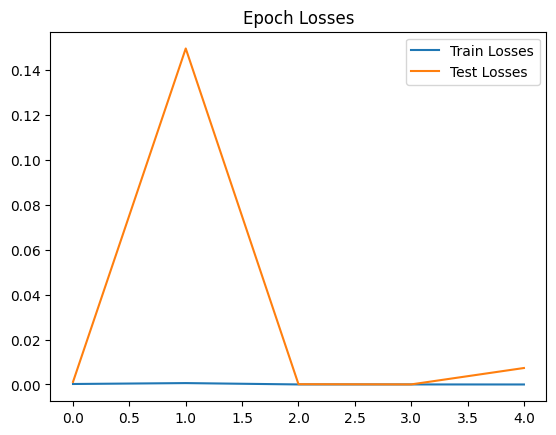

In [21]:
plt.plot(train_losses, label="Train Losses")
plt.plot(test_losses, label="Test Losses")
plt.title("Epoch Losses")
plt.legend()

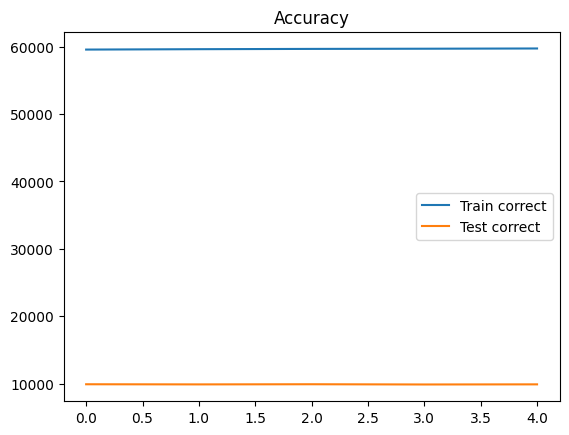

In [22]:
plt.plot(train_correct, label="Train correct")
plt.plot(test_correct, label="Test correct")
plt.title("Accuracy")
plt.legend()

In [23]:
new = DataLoader(test_data,batch_size=10000,shuffle=False)

with torch.no_grad():
    correct = 0
    for X_test,y_test in new:
        y_val = model(X_test)
        predicted = torch.max(y_val.data, 1)[1]
        correct += (predicted == y_test).sum()
print(f'Test accuracy: {correct.item()}/{len(test_data)} = {correct.item()*100/(len(test_data)):7.3f}%')

Test accuracy: 9877/10000 =  98.770%


In [24]:
print(f"Training accuracy {train_correct[-1]/600:.2f}%")
print(f"Test accuracy {test_correct[-1]/100:.2f}%")

Training accuracy 99.57%
Test accuracy 98.77%
